In [1]:
# Importing the packages

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skforecast.recursive import ForecasterEquivalentDate
import warnings
from typing import Literal

c:\Users\Christine\anaconda3\envs\ds809\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading and processing the data

# Determining the path to the data
file_dir = os.path.dirname(os.path.realpath('naive_persistence.ipynb'))
python_dir = os.path.dirname(file_dir)
data_folder = os.path.join(python_dir, 'Data')
data_file = os.path.join(data_folder, 'combined_data_cleaned_v5.csv')

# Loading the data
df = pd.read_csv(data_file, decimal = ',')
df_new = df[["TimeUTC", "DKZone", "DKPrice"]]

# Format for the datetime
date_format = '%Y-%m-%d %H:%M:%S'

# Filtering for DK1 price zone
df_DK1 = df_new[df_new['DKZone'] == 'DK1']
df_DK1 = df_DK1.drop('DKZone', axis = 1)
df_DK1.reset_index(drop=True, inplace=True)

# Saving datetime format for DK1
temp_list = []
for i in list(df_DK1["TimeUTC"]):
    n = 19
    j = i[:n]
    k = datetime.strptime(j, date_format)
    temp_list.append(k)
df_DK1.insert(0, "Time", temp_list, True)
df_DK1 = df_DK1.drop("TimeUTC", axis = 1)
df_DK1['DKPrice'] = df_DK1['DKPrice'].astype(float)

# Splitting between initial train and test set for DK1
DK1_train_set = df_DK1.loc[df_DK1['Time'] < pd.Timestamp('2025-01-01')]
DK1_train_set.reset_index(drop=True, inplace=True)
DK1_test_set = df_DK1.loc[df_DK1['Time'] >= pd.Timestamp('2025-01-01')]
DK1_test_set.reset_index(drop=True, inplace=True)

# Printing the shape for training and test date for DK1
print(f"Training data shape (DK1): {DK1_train_set.shape}")
print(f"Test data shape (DK1): {DK1_test_set.shape}")
print(f"Test set fraction (DK1): {len(DK1_test_set)/len(df_DK1):.2%}")

# Filtering for DK2 price zone
df_DK2 = df_new[df_new['DKZone'] == 'DK2']
df_DK2 = df_DK2.drop('DKZone', axis = 1)
df_DK2.reset_index(drop=True, inplace=True)

# Saving datetime format for DK2
temp_list = []
for i in list(df_DK2["TimeUTC"]):
    n = 19
    j = i[:n]
    k = datetime.strptime(j, date_format)
    temp_list.append(k)
df_DK2.insert(0, "Time", temp_list, True)
df_DK2 = df_DK2.drop("TimeUTC", axis = 1)
df_DK2['DKPrice'] = df_DK2['DKPrice'].astype(float)

# Splitting between initial train and test set for DK2
DK2_train_set = df_DK2.loc[df_DK1['Time'] < pd.Timestamp('2025-01-01')]
DK2_train_set.reset_index(drop=True, inplace=True)
DK2_test_set = df_DK2.loc[df_DK1['Time'] >= pd.Timestamp('2025-01-01')]
DK2_test_set.reset_index(drop=True, inplace=True)

# Printing the shape for training and test date for DK2
print(f"Training data shape (DK2): {DK2_train_set.shape}")
print(f"Test data shape (DK2): {DK2_test_set.shape}")
print(f"Test set fraction (DK2): {len(DK2_test_set)/len(df_DK2):.2%}")

Training data shape (DK1): (78912, 2)
Test data shape (DK1): (8760, 2)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78912, 2)
Test data shape (DK2): (8760, 2)
Test set fraction (DK2): 9.99%


In [3]:
# Defining the persistence model
def model_persistence(x):
    return x

In [4]:
# Defining the moving average model
def model_MA(L: list):
    average = np.mean(L)
    return average

In [5]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0

    values = np.zeros_like(y_true, dtype=float)
    values[mask] = 2 * np.abs(y_pred[mask] - y_true[mask]) / denominator[mask]

    return 100 * np.mean(values)

In [6]:
def _build_validation_folds(
        data: pd.DataFrame, 
        train_window: int,
        val_window: int,
        val_start: str, 
        predict_period: int, 
        stride: int
        ) -> list:
    """
    Build validation folds with:
    - fixed train_end at 2023-12-31 23:00:00
    - validation windows inside 2024
    - val_start stepping by `stride`
    """

    if not val_start:
        raise ValueError("val_start must be provided, e.g. '2024-01-01 00:00:00'")
    else:
        val_start = pd.to_datetime(val_start)

    val_window_start = val_start
    val_window_end = val_window_start + pd.Timedelta(hours=val_window - 1)
    train_end = val_start - pd.Timedelta(hours=1)
    train_start = train_end - pd.Timedelta(hours=train_window - 1)

    data_min = data["Time"].min()
    data_max = data["Time"].max()

    if train_start < data_min:
        raise ValueError(
            f"Not enough history for train_window={train_window}. "
            f"Need data from {train_start}, but dataset starts at {data_min}."
        )

    if val_window_start > data_max:
        raise ValueError(
            f"Dataset ends before 2024 validation starts. Dataset max time is {data_max}."
        )

    folds = []
    fold_no = 1

    val_start = val_window_start
    while val_start <= val_window_end:
        val_end = val_start + pd.Timedelta(hours=predict_period - 1)
        if val_end > val_window_end:
            break
        if val_end > data_max:
            break

        folds.append({
            "fold": fold_no,
            "train_start": train_start,
            "train_end": train_end,
            "val_start": val_start,
            "val_end": val_end,
        })
        fold_no += 1
        val_start = val_start + pd.Timedelta(hours=stride)

    if not folds:
        raise ValueError("No valid 2024 validation folds could be created with the given horizon/stride.")

    return folds

In [7]:
def get_baseline_predictions(
    dataset: pd.DataFrame,
    val_start: pd.Timestamp,
    val_end: pd.Timestamp,
    model_type: Literal["naive_persistence", "moving_average", "seasonal_naive"] = "seasonal_naive",
    forecast_horizon: int = 168,
    window_size: int = 168,
    dk_zone: str | None = None,
) -> dict[int, pd.DataFrame]:
    """
    Predict electricity prices from val_start to val_end in week-sized blocks
    using a purely statistical baseline model.

    The three supported model types
    ---------------------------------
    - naive_persistence : y[t] = y[t-1]         (via model_persistence)
    - moving_average    : y[t] = mean(y[t-w:t]) (via model_MA)
    - seasonal_naive    : ForecasterEquivalentDate(offset=168, n_offsets=3, agg_func=np.mean)
                          Retrained on simulated_history at the start of each week block.

    Note on seasonal_naive
    ----------------------
    The skforecast ForecasterEquivalentDate is refitted at the beginning of each
    week block using all data available up to that point (simulated_history). It
    then produces a 168-step-ahead forecast in one shot, so the hour-by-hour
    append loop is skipped for this model type — skforecast handles its own
    look-back internally.

    Parameters
    ----------
    dataset : pd.DataFrame
        Must contain exactly two columns: 'Time' (datetime) and a price column
        (any name; assumed to be the first non-Time column).
    val_start : pd.Timestamp
        First timestamp to forecast.
    val_end : pd.Timestamp
        Last timestamp to forecast (inclusive).
    model_type : {'naive_persistence', 'moving_average', 'seasonal_naive'}
        Which baseline rule to apply.
    forecast_horizon : int, default 168
        Number of hours per rolling block (one week by default).
    window_size : int, default 168
        Look-back window for the moving_average model. Ignored by other models.
    dk_zone : str, optional
        Informational label stored in returned DataFrames. Has no effect on
        the computation — baseline models are zone-agnostic.

    Returns
    -------
    dict[int, pd.DataFrame]
        Block number → DataFrame with columns ['Time', 'Prediction'].
    """
    data = dataset.copy().sort_values("Time").reset_index(drop=True)

    if "Time" not in data.columns:
        raise ValueError("dataset must contain a 'Time' column.")

    price_col = next((c for c in data.columns if c != "Time"), None)
    if price_col is None:
        raise ValueError("dataset must contain a price column in addition to 'Time'.")

    mask = (data["Time"] >= val_start) & (data["Time"] <= val_end)
    horizon_hours = data.loc[mask, "Time"].tolist()
    if not horizon_hours:
        raise ValueError("No timestamps found between val_start and val_end.")

    simulated_history = data.loc[data["Time"] < val_start].copy().reset_index(drop=True)
    if simulated_history.empty:
        raise ValueError("No historical data found before val_start.")

    # Minimum history guard
    min_lookback = {
        "naive_persistence": 1,
        "moving_average": window_size,
        "seasonal_naive": 168 * 3,  # n_offsets=3 weeks required by ForecasterEquivalentDate
    }
    required = min_lookback[model_type]
    if len(simulated_history) < required:
        raise ValueError(
            f"model_type='{model_type}' needs at least {required} historical rows before "
            f"val_start; only {len(simulated_history)} found."
        )

    def _predict_one(ts: pd.Timestamp) -> float:
        """Apply persistence or moving average for a single timestamp."""
        hist = simulated_history[price_col]

        if model_type == "naive_persistence":
            return float(model_persistence(hist.iloc[-1]))

        elif model_type == "moving_average":
            tail = hist.iloc[-window_size:].to_list()
            if any(np.isnan(v) for v in tail):
                warnings.warn(f"NaN values in look-back window at {ts}; result may be NaN.")
            return float(model_MA(tail))

        raise ValueError(f"_predict_one called for unsupported model_type '{model_type}'.")

    def _predict_block_seasonal_naive(block_hours: list[pd.Timestamp]) -> list[float]:
        """
        Refit ForecasterEquivalentDate on current simulated_history and forecast
        the entire block in one shot.
        """
        forecaster = ForecasterEquivalentDate(
            offset=pd.DateOffset(hours=168),
            n_offsets=3,
            agg_func=np.mean,
        )

        y_train = simulated_history.set_index("Time")[price_col].asfreq("h")
        forecaster.fit(y=y_train)

        preds = forecaster.predict(steps=len(block_hours))
        return preds.to_list()

    block_predictions: dict[int, pd.DataFrame] = {}
    block_no = 1
    block_start_idx = 0

    while block_start_idx < len(horizon_hours):
        block_hours = horizon_hours[block_start_idx : block_start_idx + forecast_horizon]
        target_rows = []

        if model_type == "seasonal_naive":
            # Forecast the whole block at once, then bulk-append to history
            predictions = _predict_block_seasonal_naive(block_hours)
            for ts, y_pred in zip(block_hours, predictions):
                target_rows.append({"Time": ts, price_col: y_pred})

            simulated_history = pd.concat(
                [simulated_history, pd.DataFrame(target_rows)],
                ignore_index=True,
            )

        else:
            # Hour-by-hour loop — each prediction is appended immediately so
            # the next hour's look-back sees it (matters for persistence and MA)
            for ts in block_hours:
                y_pred = _predict_one(ts)
                new_row = {"Time": ts, price_col: y_pred}
                target_rows.append(new_row)
                simulated_history = pd.concat(
                    [simulated_history, pd.DataFrame([new_row])],
                    ignore_index=True,
                )

        block_df = pd.DataFrame(target_rows).rename(columns={price_col: "Prediction"})
        block_df["Prediction"] = block_df["Prediction"].astype(float)

        block_predictions[block_no] = block_df[["Time", "Prediction"]].copy()
        if dk_zone is not None:
            block_predictions[block_no]["DKZone"] = dk_zone

        block_no += 1
        block_start_idx += forecast_horizon

    return block_predictions

In [8]:
def run_baseline_cross_validation(
    dataset: pd.DataFrame,
    dk_zone: str,
    val_start: str,
    train_window: int,
    val_window: int,
    predict_period: int,
    stride: int,
    model_type: Literal["naive_persistence", "moving_average", "seasonal_naive"] = "seasonal_naive",
    window_size: int = 168,
    print_fold_results: bool = True,
    plot: bool = True,
) -> dict:
    """
    Runs cross-validation for a statistical baseline model over all folds.

    No model training occurs — predictions are produced entirely by
    get_baseline_predictions() using the chosen statistical rule.

    For each fold:
    - Get predictions in week-sized blocks via get_baseline_predictions()
    - Calculate weekly RMSE, MAE, and SMAPE
    - Calculate daily RMSE, MAE, and SMAPE

    After all folds:
    - Aggregate metrics across all weeks and folds
    - Optionally plot daily SMAPE across the full validation timeline

    Parameters
    ----------
    dataset : pd.DataFrame
        Must contain a 'Time' column and a single price column.
    dk_zone : str
        Zone label passed through to get_baseline_predictions().
    val_start : str
        Start of the first validation fold (passed to _build_validation_folds).
    train_window : int
        Training window length in hours (used by fold builder; not used for fitting).
    val_window : int
        Validation window length in hours.
    predict_period : int
        Prediction period passed to fold builder.
    stride : int
        Number of hours to advance between folds.
    model_type : {'naive_persistence', 'moving_average', 'seasonal_naive'}
        Baseline rule to apply.
    window_size : int, default 168
        Look-back window for moving_average. Ignored by other model types.
    print_fold_results : bool, default True
        Whether to print per-fold and per-week metric tables.
    plot : bool, default True
        Whether to plot daily SMAPE across the validation timeline.

    Returns
    -------
    dict
        fold_results, weekly_results, daily_results, overall_daily_rmse/mae/smape,
        predictions, scalar overall averages, and avg_smape_day_1..7.
    """
    data = dataset.copy().sort_values("Time").reset_index(drop=True)
    target_col = next(c for c in data.columns if c != "Time")

    folds = _build_validation_folds(
        data=data,
        train_window=train_window,
        val_window=val_window,
        val_start=val_start,
        predict_period=predict_period,
        stride=stride,
    )

    fold_results = []
    weekly_results = []
    daily_results = []
    all_predictions = []

    print(f"Running baseline '{model_type}' on {len(folds)} folds (no training step)...")

    for fold in folds:
        fold_no = fold["fold"]

        val_data = data.loc[
            (data["Time"] >= fold["val_start"]) &
            (data["Time"] <= fold["val_end"])
        ].copy()

        preds_by_week = get_baseline_predictions(
            dataset=data,
            val_start=fold["val_start"],
            val_end=fold["val_end"],
            model_type=model_type,
            forecast_horizon=168,
            window_size=window_size,
            dk_zone=dk_zone,
        )

        fold_week_rmse = []
        fold_week_mae = []
        fold_week_smape = []

        for week_no, week_pred_df in preds_by_week.items():
            week_eval = week_pred_df.merge(
                val_data[["Time", target_col]],
                on="Time",
                how="left",
            )

            week_eval["fold"] = fold_no
            week_eval["week"] = week_no
            week_eval["Date"] = week_eval["Time"].dt.floor("D")

            week_rmse  = np.sqrt(mean_squared_error(week_eval[target_col], week_eval["Prediction"]))
            week_mae   = mean_absolute_error(week_eval[target_col], week_eval["Prediction"])
            week_smape = smape(week_eval[target_col].values, week_eval["Prediction"].values)

            fold_week_rmse.append(week_rmse)
            fold_week_mae.append(week_mae)
            fold_week_smape.append(week_smape)

            weekly_results.append({
                "fold":         fold_no,
                "week":         week_no,
                "week_start":   week_eval["Time"].min(),
                "week_end":     week_eval["Time"].max(),
                "weekly_rmse":  week_rmse,
                "weekly_mae":   week_mae,
                "weekly_smape": week_smape,
            })

            daily_rmse_df = (
                week_eval.groupby("Date")
                .apply(lambda g: np.sqrt(mean_squared_error(g[target_col], g["Prediction"])), include_groups=False)
                .reset_index(name="daily_rmse")
            )
            daily_mae_df = (
                week_eval.groupby("Date")
                .apply(lambda g: mean_absolute_error(g[target_col], g["Prediction"]), include_groups=False)
                .reset_index(name="daily_mae")
            )
            daily_smape_df = (
                week_eval.groupby("Date")
                .apply(lambda g: smape(g[target_col].values, g["Prediction"].values), include_groups=False)
                .reset_index(name="daily_smape")
            )

            for df in (daily_rmse_df, daily_mae_df, daily_smape_df):
                df["fold"] = fold_no
                df["week"] = week_no

            daily_results.append(
                daily_rmse_df
                .merge(daily_mae_df,   on=["Date", "fold", "week"])
                .merge(daily_smape_df, on=["Date", "fold", "week"])
            )
            all_predictions.append(week_eval)

        fold_results.append({
            "fold":           fold_no,
            "train_start":    fold["train_start"],
            "train_end":      fold["train_end"],
            "val_start":      fold["val_start"],
            "val_end":        fold["val_end"],
            "fold_avg_rmse":  np.mean(fold_week_rmse),
            "fold_avg_mae":   np.mean(fold_week_mae),
            "fold_avg_smape": np.mean(fold_week_smape),
        })

    fold_results_df    = pd.DataFrame(fold_results)
    weekly_results_df  = pd.DataFrame(weekly_results)
    daily_results_df   = pd.concat(daily_results, ignore_index=True)
    predictions_df     = pd.concat(all_predictions, ignore_index=True)

    overall_avg_weekly_rmse  = weekly_results_df["weekly_rmse"].mean()
    overall_avg_weekly_mae   = weekly_results_df["weekly_mae"].mean()
    overall_avg_weekly_smape = weekly_results_df["weekly_smape"].mean()

    overall_daily_rmse_df  = daily_results_df.groupby("Date", as_index=False)["daily_rmse"].mean().sort_values("Date")
    overall_daily_mae_df   = daily_results_df.groupby("Date", as_index=False)["daily_mae"].mean().sort_values("Date")
    overall_daily_smape_df = daily_results_df.groupby("Date", as_index=False)["daily_smape"].mean().sort_values("Date")

    overall_avg_daily_rmse  = overall_daily_rmse_df["daily_rmse"].mean()
    overall_avg_daily_mae   = overall_daily_mae_df["daily_mae"].mean()
    overall_avg_daily_smape = overall_daily_smape_df["daily_smape"].mean()

    daily_smape_by_day = (
        daily_results_df[["fold", "week", "Date", "daily_smape"]]
        .sort_values(["fold", "week", "Date"])
        .copy()
    )
    daily_smape_by_day["day_in_week"] = daily_smape_by_day.groupby(["fold", "week"]).cumcount() + 1
    avg_smape_by_day = {
        f"avg_smape_day_{day}": daily_smape_by_day.loc[
            daily_smape_by_day["day_in_week"] == day, "daily_smape"
        ].mean()
        for day in range(1, 8)
    }

    if print_fold_results:
        print("\nFold results:")
        print(fold_results_df.to_string(index=False))
        print("\nWeekly results:")
        print(weekly_results_df.to_string(index=False))

    print(f"\nAverage RMSE  across all weeks in all folds: {overall_avg_weekly_rmse:.3f}")
    print(f"Average MAE   across all weeks in all folds: {overall_avg_weekly_mae:.3f}")
    print(f"Average SMAPE across all weeks in all folds: {overall_avg_weekly_smape:.3f}")

    if plot:
        plt.figure(figsize=(14, 6))
        plt.plot(overall_daily_smape_df["Date"], overall_daily_smape_df["daily_smape"])
        plt.xlabel("Date")
        plt.ylabel("SMAPE (%)")
        plt.title(f"Daily SMAPE — {model_type} baseline across all validation folds")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    return {
        "fold_results":              fold_results_df,
        "weekly_results":            weekly_results_df,
        "daily_results":             daily_results_df,
        "overall_daily_rmse":        overall_daily_rmse_df,
        "overall_daily_mae":         overall_daily_mae_df,
        "overall_daily_smape":       overall_daily_smape_df,
        "predictions":               predictions_df,
        "overall_avg_weekly_rmse":   overall_avg_weekly_rmse,
        "overall_avg_weekly_mae":    overall_avg_weekly_mae,
        "overall_avg_weekly_smape":  overall_avg_weekly_smape,
        "overall_avg_daily_rmse":    overall_avg_daily_rmse,
        "overall_avg_daily_mae":     overall_avg_daily_mae,
        "overall_avg_daily_smape":   overall_avg_daily_smape,
        **avg_smape_by_day,
    }

Running baseline 'naive_persistence' on 1 folds (no training step)...

Average RMSE  across all weeks in all folds: 682.044
Average MAE   across all weeks in all folds: 594.769
Average SMAPE across all weeks in all folds: 181.359


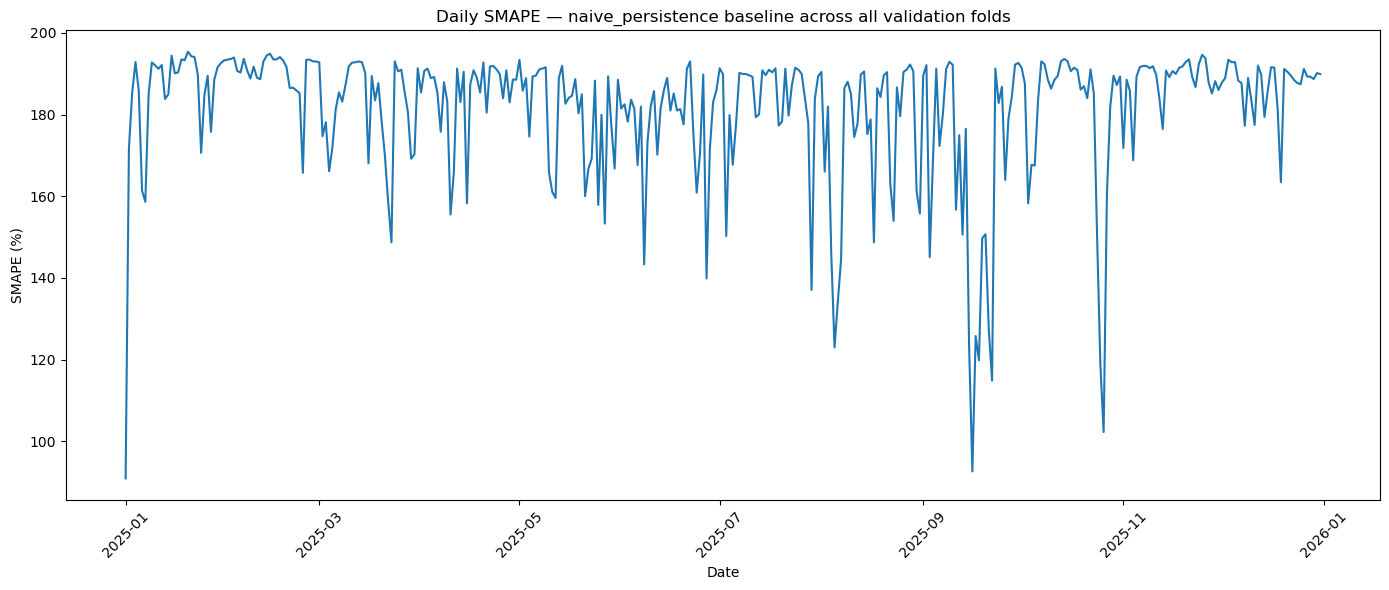

In [20]:
# Naïve Persistence DK1

results_naive_DK1 = run_baseline_cross_validation(
    dataset = df_DK1,
    dk_zone = "DK1",
    val_start=str(DK1_test_set["Time"].min()),
    train_window=len(DK1_train_set),
    val_window=len(DK1_test_set),
    predict_period=len(DK1_test_set),
    stride=len(DK1_test_set),
    model_type = "naive_persistence",
    window_size = 168,
    print_fold_results = False,
    plot = True
)

In [21]:
results_naive_DK1["fold_results"].to_csv("DK1_fold_results_naive.csv", index=False)
results_naive_DK1["weekly_results"].to_csv("DK1_weekly_results_naive.csv", index=False)
results_naive_DK1["daily_results"].to_csv("DK1_daily_results_naive.csv", index=False)
results_naive_DK1["overall_daily_rmse"].to_csv("DK1_overall_daily_rmse_naive.csv", index=False)
results_naive_DK1["overall_daily_mae"].to_csv("DK1_overall_daily_mae_naive.csv", index=False)
results_naive_DK1["overall_daily_smape"].to_csv("DK1_overall_daily_smape_naive.csv", index=False)
results_naive_DK1["predictions"].to_csv("DK1_predictions_naive.csv", index=False)

Running baseline 'naive_persistence' on 1 folds (no training step)...

Average RMSE  across all weeks in all folds: 691.593
Average MAE   across all weeks in all folds: 600.409
Average SMAPE across all weeks in all folds: 176.508


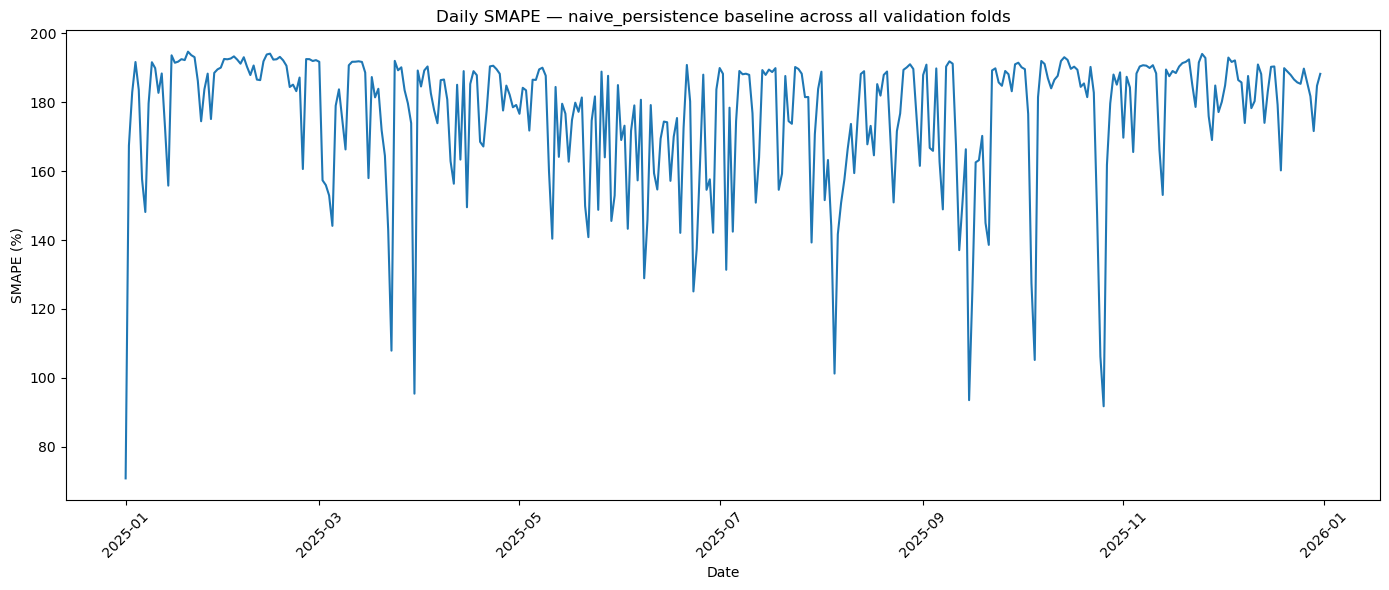

In [19]:
# Naïve Persistence DK2

results_naive_DK2 = run_baseline_cross_validation(
    dataset = df_DK2,
    dk_zone = "DK2",
    val_start=str(DK2_test_set["Time"].min()),
    train_window=len(DK2_train_set),
    val_window=len(DK2_test_set),
    predict_period=len(DK2_test_set),
    stride=len(DK2_test_set),
    model_type = "naive_persistence",
    window_size = 168,
    print_fold_results = False,
    plot = True
)

In [22]:
results_naive_DK2["fold_results"].to_csv("DK2_fold_results_naive.csv", index=False)
results_naive_DK2["weekly_results"].to_csv("DK2_weekly_results_naive.csv", index=False)
results_naive_DK2["daily_results"].to_csv("DK2_daily_results_naive.csv", index=False)
results_naive_DK2["overall_daily_rmse"].to_csv("DK2_overall_daily_rmse_naive.csv", index=False)
results_naive_DK2["overall_daily_mae"].to_csv("DK2_overall_daily_mae_naive.csv", index=False)
results_naive_DK2["overall_daily_smape"].to_csv("DK2_overall_daily_smape_naive.csv", index=False)
results_naive_DK2["predictions"].to_csv("DK2_predictions_naive.csv", index=False)

Running baseline 'moving_average' on 1 folds (no training step)...

Average RMSE  across all weeks in all folds: 379.068
Average MAE   across all weeks in all folds: 308.659
Average SMAPE across all weeks in all folds: 63.816


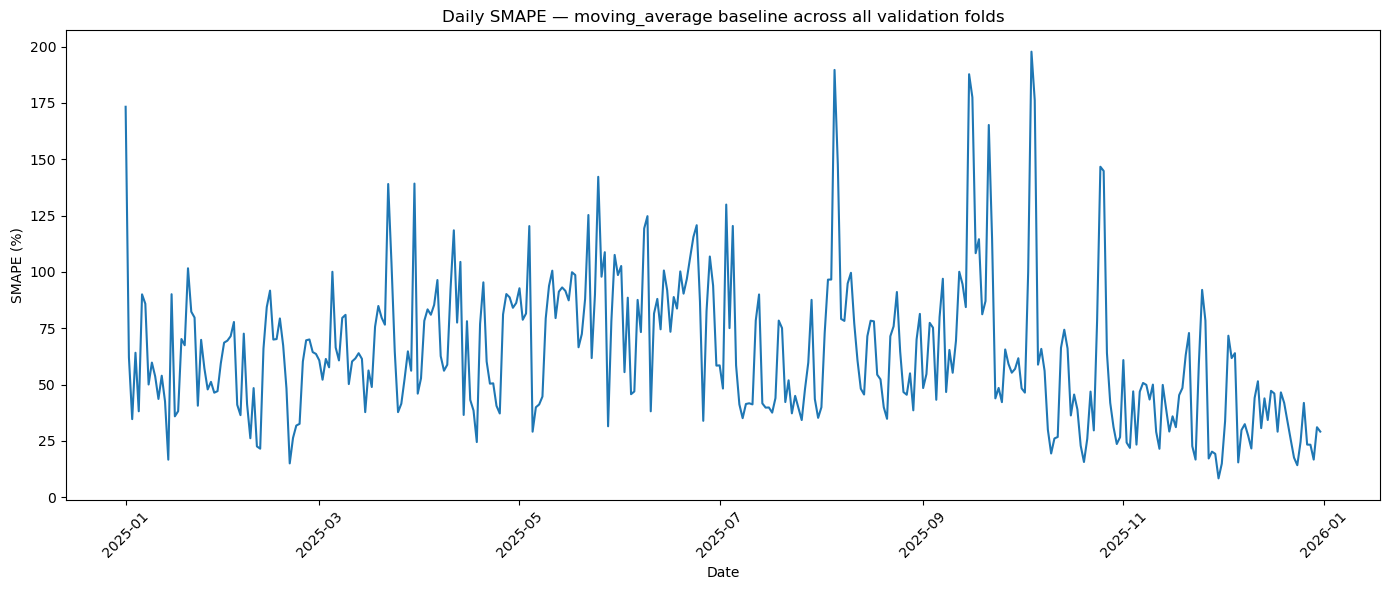

In [23]:
# Moving average

results_MA_DK1 = run_baseline_cross_validation(
    dataset = df_DK1,
    dk_zone = "DK1",
    val_start=str(DK1_test_set["Time"].min()),
    train_window=len(DK1_train_set),
    val_window=len(DK1_test_set),
    predict_period=len(DK1_test_set),
    stride=len(DK1_test_set),
    model_type = "moving_average",
    window_size = 168,
    print_fold_results = False,
    plot = True
)

In [25]:
results_MA_DK1["fold_results"].to_csv("DK1_fold_results_MA.csv", index=False)
results_MA_DK1["weekly_results"].to_csv("DK1_weekly_results_MA.csv", index=False)
results_MA_DK1["daily_results"].to_csv("DK1_daily_results_MA.csv", index=False)
results_MA_DK1["overall_daily_rmse"].to_csv("DK1_overall_daily_rmse_MA.csv", index=False)
results_MA_DK1["overall_daily_mae"].to_csv("DK1_overall_daily_mae_MA.csv", index=False)
results_MA_DK1["overall_daily_smape"].to_csv("DK1_overall_daily_smape_MA.csv", index=False)
results_MA_DK1["predictions"].to_csv("DK1_predictions_MA.csv", index=False)

Running baseline 'moving_average' on 1 folds (no training step)...

Average RMSE  across all weeks in all folds: 394.943
Average MAE   across all weeks in all folds: 322.374
Average SMAPE across all weeks in all folds: 64.953


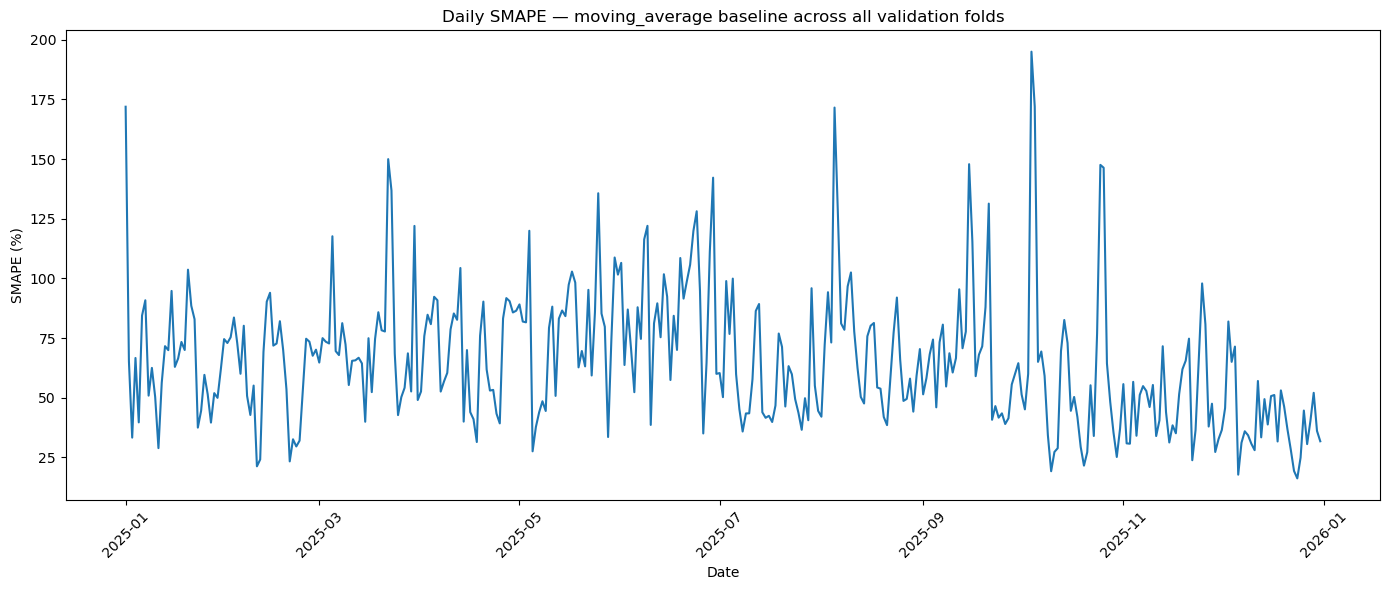

In [24]:
# Moving average

results_MA_DK2 = run_baseline_cross_validation(
    dataset = df_DK2,
    dk_zone = "DK2",
    val_start=str(DK2_test_set["Time"].min()),
    train_window=len(DK2_train_set),
    val_window=len(DK2_test_set),
    predict_period=len(DK2_test_set),
    stride=len(DK2_test_set),
    model_type = "moving_average",
    window_size = 168,
    print_fold_results = False,
    plot = True
)

In [26]:
results_MA_DK2["fold_results"].to_csv("DK2_fold_results_MA.csv", index=False)
results_MA_DK2["weekly_results"].to_csv("DK2_weekly_results_MA.csv", index=False)
results_MA_DK2["daily_results"].to_csv("DK2_daily_results_MA.csv", index=False)
results_MA_DK2["overall_daily_rmse"].to_csv("DK2_overall_daily_rmse_MA.csv", index=False)
results_MA_DK2["overall_daily_mae"].to_csv("DK2_overall_daily_mae_MA.csv", index=False)
results_MA_DK2["overall_daily_smape"].to_csv("DK2_overall_daily_smape_MA.csv", index=False)
results_MA_DK2["predictions"].to_csv("DK2_predictions_MA.csv", index=False)

Running baseline 'seasonal_naive' on 1 folds (no training step)...

Average RMSE  across all weeks in all folds: 441.690
Average MAE   across all weeks in all folds: 351.112
Average SMAPE across all weeks in all folds: 69.775


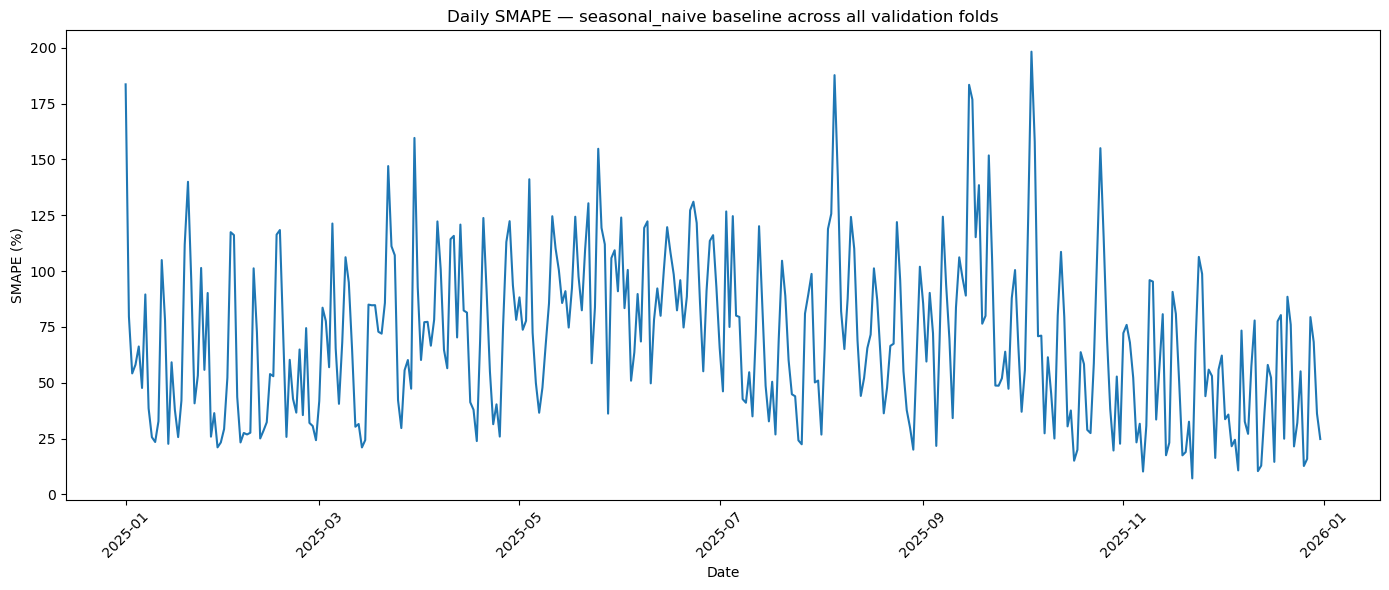

In [ ]:
# Seasonal naïve

results_seasonal_DK1 = run_baseline_cross_validation(
    dataset = df_DK1,
    dk_zone = "DK1",
    val_start=str(DK1_test_set["Time"].min()),
    train_window=len(DK1_train_set),
    val_window=len(DK1_test_set),
    predict_period=len(DK1_test_set),
    stride=len(DK1_test_set),
    model_type = "seasonal_naive",
    window_size = 168,
    print_fold_results = False,
    plot = True
)

In [ ]:
results_seasonal_DK1["fold_results"].to_csv("DK1_fold_results_seasonal.csv", index=False)
results_seasonal_DK1["weekly_results"].to_csv("DK1_weekly_results_seasonal.csv", index=False)
results_seasonal_DK1["daily_results"].to_csv("DK1_daily_results_seasonal.csv", index=False)
results_seasonal_DK1["overall_daily_rmse"].to_csv("DK1_overall_daily_rmse_seasonal.csv", index=False)
results_seasonal_DK1["overall_daily_mae"].to_csv("DK1_overall_daily_mae_seasonal.csv", index=False)
results_seasonal_DK1["overall_daily_smape"].to_csv("DK1_overall_daily_smape_seasonal.csv", index=False)
results_seasonal_DK1["predictions"].to_csv("DK1_predictions_seasonal.csv", index=False)